In [1]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

# ── Step 1: Load the dataset ──────────────────────────────────────────────
# 569 samples, 30 features per sample (tumour measurements like radius,
# texture, perimeter, area, smoothness...)
# Target: 0 = malignant (cancerous), 1 = benign (non-cancerous)
df = load_breast_cancer()
X = df.data    # shape: (569, 30)
y = df.target  # shape: (569,)

# ── Step 2: Train/test split ─────────────────────────────────────────────
# 80% of data for training, 20% for testing
# random_state=42 ensures the same split every run (reproducible)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# ── Step 3: Feature scaling ───────────────────────────────────────────────
# Raw features have wildly different ranges:
#   radius: 6–28,  area: 143–2500,  smoothness: 0.05–0.16
# Sigmoid gets saturated (gradient vanishes) on large inputs
# StandardScaler transforms each feature to mean=0, std=1
# IMPORTANT: fit ONLY on training data, then transform both sets
# (to avoid data leakage — the test set must stay "unseen")
sc = StandardScaler()
X_train = sc.fit_transform(X_train)  # learn mean/std from train, apply
X_test  = sc.transform(X_test)       # apply same mean/std to test

# ── Step 4: Build the model ───────────────────────────────────────────────
# Sequential = layers stacked one after another (same as our MLP)
# Dense(1) = one output neuron (binary classification needs only 1)
# activation='sigmoid' = outputs probability between 0 and 1
# input_shape=(30,) = 30 input features
#
# This is equivalent to the single-layer network from practical 5,
# but now Keras handles weights, backprop, and updates automatically
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],))
])

# ── Step 5: Compile — choose the learning strategy ───────────────────────
# optimizer='adam'  : smarter version of gradient descent (adaptive learning rate)
# loss='binary_crossentropy' : standard loss for binary (0/1) classification
#                              better than MSE for classification tasks
# metrics=['accuracy'] : track accuracy alongside loss during training
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ── Step 6: Train ─────────────────────────────────────────────────────────
# epochs=5 : pass through all training data 5 times
# Keras automatically does: forward pass → loss → backprop → weight update
# It prints loss and accuracy after each epoch
model.fit(X_train, y_train, epochs=5)

# ── Step 7: Predict and evaluate ─────────────────────────────────────────
# predict() returns raw sigmoid probabilities (e.g. 0.87, 0.03, 0.91...)
# A threshold of 0.5 converts to class: >0.5 → benign(1), ≤0.5 → malignant(0)
y_pred = model.predict(X_test)

# evaluate() runs the model on test data and returns loss + accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")

# ── Bonus: see actual predictions vs truth ────────────────────────────────
y_pred_class = (y_pred > 0.5).astype(int).flatten()
for i in range(5):
    status = "✓" if y_pred_class[i] == y_test[i] else "✗"
    label  = "Benign" if y_pred_class[i] == 1 else "Malignant"
    print(f"  {status} Predicted: {label:10s}  Actual: {'Benign' if y_test[i]==1 else 'Malignant'}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1670 - loss: 1.3919
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2022 - loss: 1.2421
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2615 - loss: 1.1054
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3231 - loss: 0.9819  
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3912 - loss: 0.8755 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3947 - loss: 0.8447 
Test accuracy: 0.3947
  ✓ Predicted: Benign      Actual: Benign
  ✗ Predicted: Benign      Actual: Malignant
  ✗ Predicted: Benign      Actual: Malignant
  ✗ Predicted: Malignant   Actual: Benign
  ✓ Predicted: Benign      Actual: Benign


ML Pipeline — what this code does step by step

1
Load dataset
569 tumour samples · 30 features each · labels: 0=malignant, 1=benign

2
Train/Test split (80/20)
455 training samples · 114 test samples · random_state=42

3
StandardScaler
Each feature → mean 0, std 1 · fit on train only · prevents data leakage

4
Model: Dense(1, sigmoid)
30 inputs → 1 sigmoid neuron · 31 learnable parameters (30 weights + 1 bias)

5
Compile: Adam + Binary Crossentropy
Adaptive optimizer · classification-optimised loss function

6
Train for 5 epochs
Forward pass → loss → backprop → weight update · Keras handles all of it

7
Evaluate on test set
Accuracy = correct predictions / total test samples

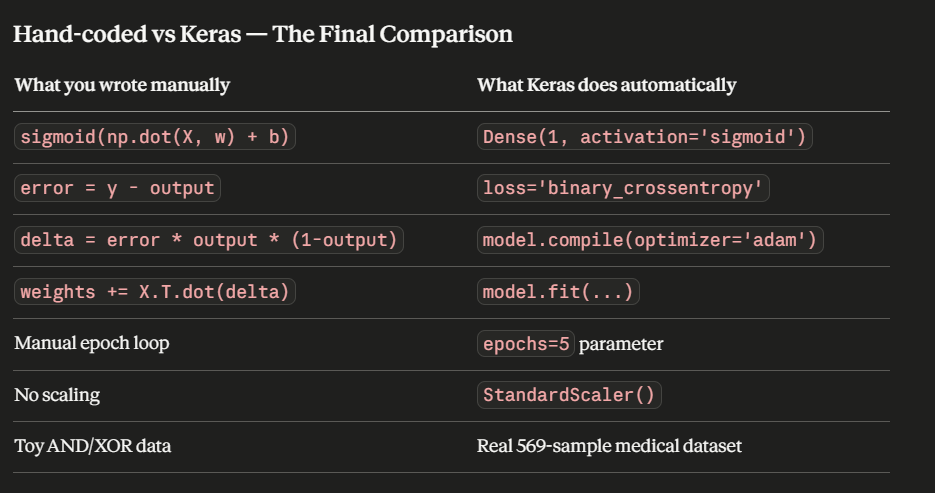